In [1]:
from pathlib import Path

def find_project_root(start_path: Path) -> Path:
    """
    Find project root folder by checking for requirements.txt and data folder.
    """
    start_path = start_path.resolve()

    for path in [start_path] + list(start_path.parents):
        if (path / "requirements.txt").exists() and (path / "data").exists():
            return path

    return start_path


PROJECT_ROOT = find_project_root(Path.cwd())

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TRAIN_DATA_PATH = PROCESSED_DIR / "train_data.csv"
TEST_DATA_PATH = PROCESSED_DIR / "test_data.csv"

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
METRICS_DIR = REPORTS_DIR / "metrics"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Train data path:", TRAIN_DATA_PATH)
print("Test data path:", TEST_DATA_PATH)
print("Models folder:", MODELS_DIR)
print("Figures folder:", FIGURES_DIR)
print("Metrics folder:", METRICS_DIR)

Project root: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05
Train data path: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/data/processed/train_data.csv
Test data path: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/data/processed/test_data.csv
Models folder: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/models
Figures folder: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures
Metrics folder: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/metrics


Load train and test datasets

In [2]:
import pandas as pd

if not TRAIN_DATA_PATH.exists():
    raise FileNotFoundError(
        f"train_data.csv not found at: {TRAIN_DATA_PATH}\n"
        "Please run 04_train_test_split.ipynb first."
    )

if not TEST_DATA_PATH.exists():
    raise FileNotFoundError(
        f"test_data.csv not found at: {TEST_DATA_PATH}\n"
        "Please run 04_train_test_split.ipynb first."
    )

train_data = pd.read_csv(TRAIN_DATA_PATH)
test_data = pd.read_csv(TEST_DATA_PATH)

print("Train and test datasets loaded successfully.")
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

print("\nTrain columns:")
print(train_data.columns.tolist())

print("\nTest columns:")
print(test_data.columns.tolist())

display(train_data.head())
display(test_data.head())

Train and test datasets loaded successfully.
Train shape: (31278, 2)
Test shape: (7820, 2)

Train columns:
['clean_text', 'label']

Test columns:
['clean_text', 'label']


,clean_text,label
0,catalan government appeal direct rule constitu...,1
1,sick lie cnn luck today turn cnn day meme spre...,0
2,cop ask mayor remove black life matter banner ...,0
3,racist barber pull gun black man asked haircut...,0
4,lol democrat congressman say best way fight fa...,0


,clean_text,label
0,sept law weakens international relation saudi ...,1
1,breaking trump top insane weekend announcing n...,0
2,ugandan mp get work extending president rule s...,1
3,trump belief obama born united state campaign ...,1
4,colbert rundown harriet tubman news gonna piss...,0


Prepare X and y

In [3]:
required_columns = ["clean_text", "label"]

for column in required_columns:
    if column not in train_data.columns:
        raise ValueError(f"Required column missing in train_data: {column}")

    if column not in test_data.columns:
        raise ValueError(f"Required column missing in test_data: {column}")


train_data = train_data.copy()
test_data = test_data.copy()

train_data["clean_text"] = train_data["clean_text"].fillna("").astype(str)
test_data["clean_text"] = test_data["clean_text"].fillna("").astype(str)

train_data["label"] = train_data["label"].astype(int)
test_data["label"] = test_data["label"].astype(int)

train_data = train_data[train_data["clean_text"].str.strip() != ""]
test_data = test_data[test_data["clean_text"].str.strip() != ""]

X_train = train_data["clean_text"]
y_train = train_data["label"]

X_test = test_data["clean_text"]
y_test = test_data["label"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

X_train shape: (31278,)
y_train shape: (31278,)
X_test shape: (7820,)
y_test shape: (7820,)

Training class distribution:
label
1    16957
0    14321
Name: count, dtype: int64

Testing class distribution:
label
1    4239
0    3581
Name: count, dtype: int64


TF-IDF feature extraction

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF feature extraction completed.")
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

TF-IDF feature extraction completed.
Training TF-IDF shape: (31278, 5000)
Testing TF-IDF shape: (7820, 5000)


Train Logistic Regression model

In [5]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model training completed.")

Logistic Regression model training completed.


Make predictions

In [6]:
y_pred = lr_model.predict(X_test_tfidf)

# Probability of class 1 = Real News
y_pred_prob = lr_model.predict_proba(X_test_tfidf)[:, 1]

print("Predictions completed.")
print("y_pred shape:", y_pred.shape)
print("y_pred_prob shape:", y_pred_prob.shape)

print("\nFirst 10 predicted labels:")
print(y_pred[:10])

print("\nFirst 10 actual labels:")
print(y_test.values[:10])

Predictions completed.
y_pred shape: (7820,)
y_pred_prob shape: (7820,)

First 10 predicted labels:
[1 0 1 1 0 1 1 0 1 1]

First 10 actual labels:
[1 0 1 1 0 1 1 0 1 1]


Evaluation metrics

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)

weighted_precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

# Fake News = 0
fake_precision = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
fake_recall = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
fake_f1 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

# Real News = 1
real_precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
real_recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
real_f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

roc_auc = roc_auc_score(y_test, y_pred_prob)

print("Logistic Regression Evaluation Results")
print("--------------------------------------")
print("Accuracy:", round(accuracy, 4))
print("Weighted Precision:", round(weighted_precision, 4))
print("Weighted Recall:", round(weighted_recall, 4))
print("Weighted F1-score:", round(weighted_f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nFake News Class Metrics")
print("Precision:", round(fake_precision, 4))
print("Recall:", round(fake_recall, 4))
print("F1-score:", round(fake_f1, 4))

print("\nReal News Class Metrics")
print("Precision:", round(real_precision, 4))
print("Recall:", round(real_recall, 4))
print("F1-score:", round(real_f1, 4))

Logistic Regression Evaluation Results
--------------------------------------
Accuracy: 0.9872
Weighted Precision: 0.9872
Weighted Recall: 0.9872
Weighted F1-score: 0.9872
ROC-AUC: 0.999

Fake News Class Metrics
Precision: 0.9907
Recall: 0.9813
F1-score: 0.986

Real News Class Metrics
Precision: 0.9843
Recall: 0.9922
F1-score: 0.9883


Classification report

In [8]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=["Fake News", "Real News"],
    zero_division=0
)

print("Classification Report")
print("---------------------")
print(report)

Classification Report
---------------------
              precision    recall  f1-score   support

   Fake News       0.99      0.98      0.99      3581
   Real News       0.98      0.99      0.99      4239

    accuracy                           0.99      7820
   macro avg       0.99      0.99      0.99      7820
weighted avg       0.99      0.99      0.99      7820



Save metrics CSV

In [9]:
metrics_data = {
    "model": ["Logistic Regression"],
    "accuracy": [accuracy],
    "precision": [weighted_precision],
    "recall": [weighted_recall],
    "f1_score": [weighted_f1],
    "roc_auc": [roc_auc],
    "fake_precision": [fake_precision],
    "fake_recall": [fake_recall],
    "fake_f1": [fake_f1],
    "real_precision": [real_precision],
    "real_recall": [real_recall],
    "real_f1": [real_f1]
}

metrics_df = pd.DataFrame(metrics_data)

metrics_output_path = METRICS_DIR / "logistic_regression_metrics.csv"
metrics_df.to_csv(metrics_output_path, index=False)

display(metrics_df)

print("Logistic Regression metrics saved to:", metrics_output_path)

,model,accuracy,precision,recall,f1_score,roc_auc,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1
0,Logistic Regression,0.987212,0.98724,0.987212,0.987207,0.998966,0.990696,0.98129,0.985971,0.98432,0.992215,0.988252


Logistic Regression metrics saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/metrics/logistic_regression_metrics.csv


Confusion matrix

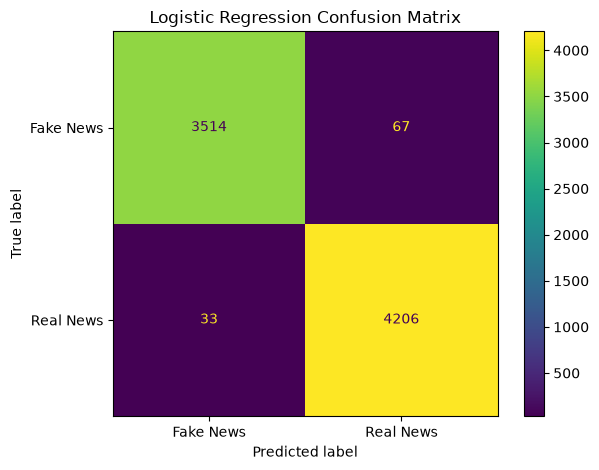

Confusion matrix saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/lr_confusion_matrix.png


In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Fake News", "Real News"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()

confusion_matrix_path = FIGURES_DIR / "lr_confusion_matrix.png"
plt.savefig(confusion_matrix_path)
plt.show()

print("Confusion matrix saved to:", confusion_matrix_path)

ROC curve

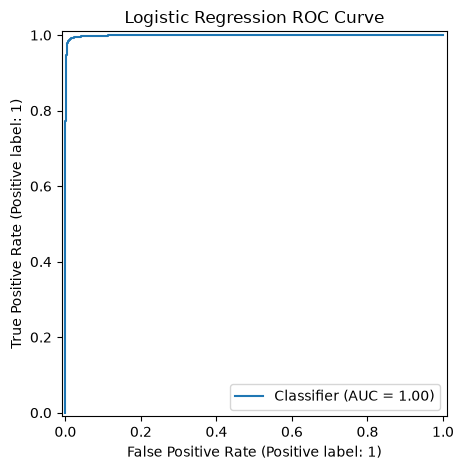

ROC curve saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/lr_roc_curve.png


In [11]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_pred_prob
)

plt.title("Logistic Regression ROC Curve")
plt.tight_layout()

roc_curve_path = FIGURES_DIR / "lr_roc_curve.png"
plt.savefig(roc_curve_path)
plt.show()

print("ROC curve saved to:", roc_curve_path)

Save model and vectorizer

In [12]:
import joblib

model_output_path = MODELS_DIR / "logistic_regression_model.joblib"
vectorizer_output_path = MODELS_DIR / "tfidf_vectorizer.joblib"

joblib.dump(lr_model, model_output_path)
joblib.dump(tfidf_vectorizer, vectorizer_output_path)

print("Model saved to:", model_output_path)
print("TF-IDF vectorizer saved to:", vectorizer_output_path)

Model saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/models/logistic_regression_model.joblib
TF-IDF vectorizer saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/models/tfidf_vectorizer.joblib


Verify saved model

In [13]:
loaded_model = joblib.load(model_output_path)
loaded_vectorizer = joblib.load(vectorizer_output_path)

sample_text = X_test.iloc[0]
sample_vector = loaded_vectorizer.transform([sample_text])

sample_prediction = loaded_model.predict(sample_vector)[0]
sample_probability = loaded_model.predict_proba(sample_vector)[0]

label_mapping = {
    0: "Fake News",
    1: "Real News"
}

print("Sample text:")
print(sample_text[:500])

print("\nActual label:", label_mapping[y_test.iloc[0]])
print("Predicted label:", label_mapping[sample_prediction])

print("\nFake probability:", round(sample_probability[0] * 100, 2), "%")
print("Real probability:", round(sample_probability[1] * 100, 2), "%")

Sample text:
sept law weakens international relation saudi cabinet say dubai reuters saudi arabia said monday law allowing citizen sue kingdom sept attack represented threat international relation urged congress act prevent dangerous consequence new legislation cabinet weekly meeting capital riyadh also said law known jasta represented violation leading principle preventing lawsuit government regulated international relation hundred year weakening sovereign immunity affect country including united state stat

Actual label: Real News
Predicted label: Real News

Fake probability: 0.98 %
Real probability: 99.02 %


Prediction function for cleaned text

In [14]:
def predict_cleaned_news(cleaned_news_text):
    """
    Predict Fake/Real news using already cleaned English text.
    """

    news_vector = tfidf_vectorizer.transform([cleaned_news_text])
    prediction = lr_model.predict(news_vector)[0]
    probabilities = lr_model.predict_proba(news_vector)[0]

    fake_probability = probabilities[0]
    real_probability = probabilities[1]

    if prediction == 0:
        result = "Fake News"
        confidence = fake_probability
    else:
        result = "Real News"
        confidence = real_probability

    return {
        "prediction": result,
        "confidence": confidence,
        "fake_probability": fake_probability,
        "real_probability": real_probability
    }


test_text = X_test.iloc[1]
output = predict_cleaned_news(test_text)

print("Prediction:", output["prediction"])
print("Confidence:", round(output["confidence"] * 100, 2), "%")
print("Fake Probability:", round(output["fake_probability"] * 100, 2), "%")
print("Real Probability:", round(output["real_probability"] * 100, 2), "%")

Prediction: Fake News
Confidence: 99.25 %
Fake Probability: 99.25 %
Real Probability: 0.75 %


Important TF-IDF features

In [15]:
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = lr_model.coef_[0]

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

top_fake_features = feature_importance_df.sort_values(
    by="coefficient",
    ascending=True
).head(20)

top_real_features = feature_importance_df.sort_values(
    by="coefficient",
    ascending=False
).head(20)

print("Top features related to Fake News:")
display(top_fake_features)

print("Top features related to Real News:")
display(top_real_features)

Top features related to Fake News:


,feature,coefficient
4755,via,-9.820872
4769,video,-8.776972
2082,image,-6.706657
3489,read,-6.262009
1839,gop,-5.262345
3295,president trump,-5.100534
1985,hillary,-4.876851
1588,featured image,-4.790379
1587,featured,-4.685912
4908,wire,-4.357512


Top features related to Real News:


,feature,coefficient
3691,reuters,20.319393
3801,said,14.419841
4839,washington reuters,8.445142
3286,president donald,4.941812
4858,wednesday,4.421061
4837,washington,4.330994
3695,reuters president,4.204862
4642,tuesday,3.930124
4471,thursday,3.843628
1752,friday,3.422006



Plot Fake News important features

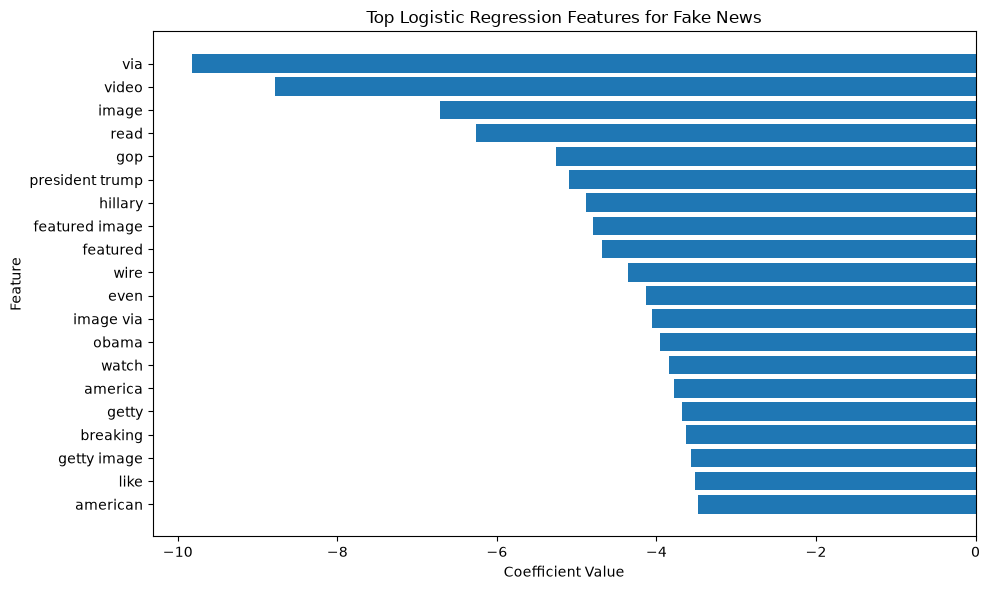

Top fake features graph saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/lr_top_fake_features.png


In [16]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_fake_features["feature"],
    top_fake_features["coefficient"]
)

plt.title("Top Logistic Regression Features for Fake News")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.gca().invert_yaxis()

plt.tight_layout()

fake_features_path = FIGURES_DIR / "lr_top_fake_features.png"
plt.savefig(fake_features_path)
plt.show()

print("Top fake features graph saved to:", fake_features_path)

Plot Real News important features

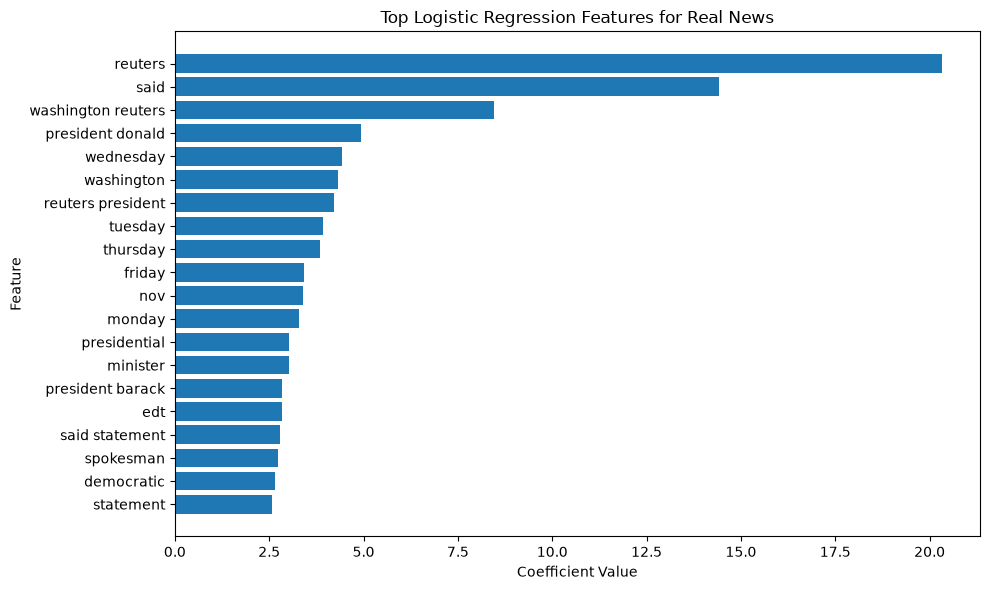

Top real features graph saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/lr_top_real_features.png


In [17]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_real_features["feature"],
    top_real_features["coefficient"]
)

plt.title("Top Logistic Regression Features for Real News")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.gca().invert_yaxis()

plt.tight_layout()

real_features_path = FIGURES_DIR / "lr_top_real_features.png"
plt.savefig(real_features_path)
plt.show()

print("Top real features graph saved to:", real_features_path)